# Модели пространственных данных

**Модель пространственных данных** — это концептуальная схема, с помощью которой реальные географические объекты представляются в структурированной и организованной форме. Она определяет, как пространственные объекты описываются, хранятся и обрабатываются в ГИС.

Существует два основных типа моделей пространственных данных:

**1. Векторная модель данных**

Представляет географические объекты в виде отдельных геометрических элементов:

- **Точки** (например, расположение автобусной остановки)
- **Линии** (например, дороги, реки)
- **Полигоны** (например, контуры зданий, административные границы)

**2. Растровая модель данных**

Представляет пространство как непрерывную поверхность, разделённую на регулярную сетку ячеек (пикселей), каждая из которых содержит значение (например, спутниковые снимки или данные о высоте рельефа).


## 0. Импорт библиотек


In [6]:
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon

- [**GeoPandas**](https://geopandas.org/) (`geopandas`) — расширение библиотеки pandas, которое упрощает работу с геопространственными данными. Позволяет загружать, обрабатывать и анализировать пространственные наборы данных в различных форматах.

- [**Shapely**](https://shapely.readthedocs.io/) (`shapely.geometry`) — библиотека для создания и работы с геометрическими объектами, такими как Point, LineString и Polygon.


## 1. Векторные данные


В этом разделе мы рассмотрим, как устроены векторные данные, а также научимся создавать и изменять их с помощью Python.

Геометрические объекты формируются на основе кортежей координат и представлены несколькими базовыми типами:

- **Point** — точка, представляющая отдельное местоположение в пространстве. Задаётся двумя координатами (x, y) или тремя (x, y, z).

- **LineString** — линия, состоящая как минимум из двух соединённых точек, образующих непрерывный путь.

- **Polygon** — полигон (многоугольник), описывающий замкнутую область. Задаётся минимум тремя кортежами координат, формирующими внешнюю границу (так называемое внешнее кольцо). Полигон также может содержать одно или несколько внутренних колец (отверстий).

Помимо простых геометрий существуют **коллекции геометрий**, которые используются для объединения нескольких объектов одного типа:

- **MultiPoint** — набор отдельных точек.
- **MultiLineString** — группа линий (LineString), каждая из которых состоит из соединённых точек.
- **MultiPolygon** — совокупность нескольких полигонов, каждый со своей внешней границей и, при необходимости, внутренними отверстиями.


### 1.1 Точки - Points

**Точки** используются для представления объектов, которые имеют конкретное местоположение, но не обладают площадью или длиной. Например, отдельное дерево, автобусная остановка или станция наблюдений.

Давайте создадим точку на основе известных координат — долготы и широты.


POINT (16.36736 48.198942)
<class 'shapely.geometry.point.Point'>


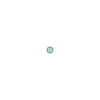

In [7]:
# Задаём координаты
long = 16.367360
lat = 48.198942

# Создаём объект Point
point = Point(long, lat)

# Смотрим результат
print(point)
print(type(point))
display(point)


Объект `Point`, который мы видим, создаётся с помощью библиотеки **Shapely** и использует формат, основанный на библиотеке **GEOS** — геометрическом движке, лежащем в основе многих ГИС-инструментов, таких как PostGIS и QGIS.

Сам по себе объект `Point` просто представляет местоположение в пространстве. Однако мы можем сделать его гораздо более полезным, преобразовав в **GeoDataFrame** с помощью библиотеки **GeoPandas**.

**GeoDataFrame** — это расширение обычного DataFrame из библиотеки pandas, которое содержит специальный столбец `geometry` для хранения геометрических объектов. Это позволяет хранить не только пространственные координаты, но и дополнительные **атрибуты** (например, название, тип или идентификатор объекта).


In [8]:
# Создаём дополнительные атрибуты
data = {
    'name': ['Technical University of Vienna'],
    'type': ['University'],
    'geometry': [point]
}

# Создаём GeoDataFrame и задаём систему координат (CRS)
gdf = gpd.GeoDataFrame(data, crs="EPSG:4326")

# Смотрим результат
print(type(gdf))
gdf


<class 'geopandas.geodataframe.GeoDataFrame'>


,name,type,geometry
0,Technical University of Vienna,University,POINT (16.36736 48.19894)


По структуре этот формат действительно похож на обычный DataFrame, однако есть одно важное отличие: в нём присутствует специальный столбец **geometry**. Именно он определяет **пространственное положение** каждого объекта и делает возможным выполнение географических операций.


Давайте отобразим точку на карте с помощью метода `explore()`.

Чтобы он корректно работал, необходимо установить следующие библиотеки:

- **folium** — используется для создания интерактивных веб-карт
- **mapclassify** — применяется для классификации данных (например, при построении цветовых шкал и легенд)


In [9]:
# Отображаем результат на интерактивной карте
gdf.explore(tiles='cartodbpositron')

Это уже не просто случайная точка с координатами — это **геопространственные данные**.
Указав систему координат, мы точно понимаем, где именно расположен этот объект на нашей планете.


### 1.2 Линии

**Линии** используются для представления объектов, которые имеют **длину**, но не обладают площадью. С их помощью моделируют линейные объекты — дороги, реки, пешеходные маршруты и вообще всё, что протягивается между двумя или более точками.

Поскольку мы уже разобрали все шаги на примере точки, теперь сразу перейдём к созданию **GeoDataFrame** на основе линии и её визуализации на карте.


In [10]:
long = 16.367360
lat = 48.198942

# Задаём координаты линии
coords_line = [
    (16.367360, 48.198942), 
    (16.370267, 48.196514), 
    (16.369908, 48.198917)
]

# Создаём объект LineString
line = LineString(coords_line)

# Создаём GeoDataFrame и задаём систему координат (CRS)
gdf_line = gpd.GeoDataFrame([{'geometry': line}], crs="EPSG:4326")

# Отображаем линию на интерактивной карте
gdf_line.explore(tiles='cartodbpositron')


### 1.3 Полигоны

**Полигоны** используются для представления объектов, которые имеют **площадь и границы**. С их помощью моделируют замкнутые пространства — здания, парки, озёра, районы и другие географические территории. Полигон задаётся последовательностью координат, образующих замкнутое кольцо — первая и последняя точки должны совпадать.

Поскольку ранее мы создали линию на основе реальных объектов в Санкт-Петербург, теперь преобразуем эти же координаты в **Polygon**, создадим **GeoDataFrame** и отобразим его на карте.


In [11]:
# создаём полион
polygon =  Polygon(coords_line)

gdf_polygon = gpd.GeoDataFrame([{'geometry': polygon}], crs="EPSG:4326")

gdf_polygon.explore(tiles='cartodbpositron')


## 2. Итог

В этом разделе мы познакомились с основами **моделей пространственных данных**, уделив особое внимание **векторной модели**.
Мы разобрали, как реальные географические объекты могут быть представлены в виде **точек**, **линий** и **полигонов**, а также научились работать с этими геометриями с помощью библиотек **Shapely** и **GeoPandas**.

Теперь вы умеете:

- создавать базовые геометрические объекты на основе координат;
- сохранять их в формате GeoDataFrame;
- дополнять их атрибутами и визуализировать на простой интерактивной карте.
